Pemeriksaan versi Python, sistem operasi, jumlah inti CPU, serta memastikan ketersediaan pustaka utama seperti pandas, numpy, pyarrow, dan matplotlib.

In [28]:
import sys, platform, multiprocessing

print("Python:", sys.version.split()[0])
print("OS :", platform.system(), platform.release())
print("CPU(s):", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama} : {mod.__version__}")
  except ImportError:
    print(f"{nama:11s} : Belum Terpasang")

Python: 3.13.15
OS : Linux 6.6.122+
CPU(s): 2
pandas : 2.2.3
numpy : 2.1.3
pyarrow : 23.0.1
matplotlib : 3.10.0


Pemeriksaan alokasi sumber daya di lingkungan Colab, termasuk sisa RAM (free -h), kapasitas penyimpanan disk (df -h), dan versi Java yang terpasang.

In [29]:
!free -h
!df -h / content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       3.2Gi       5.2Gi       2.2Mi       4.7Gi       9.5Gi
Swap:             0B          0B          0B
df: content: No such file or directory
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  20% /
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Menghubungkan (mount) Google Drive ke sesi Colab dan membuat direktori kerja (DIR_Kerja) serta direktori penyimpanan (DIR_SIMPAN) untuk merapikan file proyek.

In [4]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_Kerja = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Pratikum1"
os.makedirs(DIR_Kerja, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'pengukuran_kinerja.csv', 'agregasi_per_jam.parquet', 'distribusi_per_jam.png']


Membuat fungsi kustom bernama ukur untuk memantau kinerja eksekusi kode, yang mencatat durasi waktu (dalam detik) dan perubahan penggunaan memori (RSS dalam MB).

In [5]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur (label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter()
    delta = rss_mb() -m0
    catatan.append({"Langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

Mengunduh dataset "Yellow Taxi Tripdata" bulan Januari 2023 dalam format Parquet jika file tersebut belum ada di direktori kerja.

In [6]:
import urllib.request

URL =("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_Kerja, "yellow_tripdata_2023-01.parquet")

if not os.path.exists (PATH):
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

  print("Ukuran fille:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 219.75 s | RSS +1.8 MB
Ukuran fille: 45.5 MB


Membaca metadata dari file Parquet menggunakan pustaka pyarrow untuk melihat jumlah baris, jumlah kolom, dan nama-nama kolom tanpa memuat seluruh data ke memori.

In [7]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group:", meta.num_row_groups)
print("Nama kolom:", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group: 1
Nama kolom: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


Membandingkan penggunaan memori ketika memuat seluruh kolom versus memuat hanya kolom-kolom yang diperlukan menggunakan pandas.  

In [8]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df=ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum()/1024**2, 1), "MB")
df.head()

[baca semua kolom] 222.29 s | RSS +499.0 MB
Dimensi: (3066766, 19)
Memori: 565.6 MB
[baca kolom terpilih] 223.83 s | RSS +227.7 MB
Dimensi: (3066766, 8)
Memori: 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


Menganalisis penggunaan memori yang lebih mendalam (deep memory usage) untuk melihat beban memori pada masing-masing kolom DataFrame.

In [9]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


Mengoptimalkan penggunaan memori DataFrame dengan teknik downcasting (mengubah tipe data ke ukuran yang lebih kecil, misalnya float64 ke float32) dan mengubah kolom menjadi tipe kategori.

In [10]:
sebelum = df.memory_usage(deep=True).sum()/ 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


Menambahkan kolom baru untuk durasi perjalanan (dalam menit), melihat statistik deskriptif, mengecek nilai kosong (NaN), serta mengidentifikasi data-data yang anomali (seperti jarak atau durasi negatif/nol).

In [11]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <=0"           : (df["trip_distance"] <= 0).sum(),
    "durasi<= 0"          : (df["durasi_menit"]<=0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"]>180). sum(),
    "total_amount <= 0"   : (df["total_amount"]<=0).sum(),
}

for k, v in anomali.items():
  print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <=0             : 45,862 baris (1.50%)
durasi<= 0            : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


Menyaring data dengan menghapus baris-baris yang mengandung anomali (durasi tidak wajar atau jarak nol), sehingga menghasilkan dataframe yang bersih (variabel bersih).

In [12]:
layak = (
    (df["trip_distance"]>0) & (df["trip_distance"] <100) &
    df["durasi_menit"].between(1, 180) & (df["total_amount"]>0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len (bersih):,} baris (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


Menyimpan dataframe yang sudah bersih ke dalam format CSV dan membandingkan pembengkakan ukuran filenya terhadap format Parquet.

In [13]:
CSV = os.path.join(DIR_Kerja, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 267.80 s | RSS +5.7 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


Melakukan agregasi data CSV secara bertahap (metode chunking) untuk menghitung total pendapatan berdasarkan jam tanpa membebani memori utama.

In [14]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 271.90 s | RSS +20.5 MB
2,986,911 baris | rata-rata total_amount = 27.33


Latihan 2
Ukuran chunk= 100.000

In [15]:
def agregasi_bertahap(path, ukuran_chunk=100_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 276.15 s | RSS +1.3 MB
2,986,911 baris | rata-rata total_amount = 27.33


Latihan 2
Ukuran chunk=1.000.000

In [16]:
def agregasi_bertahap(path, ukuran_chunk=1_000_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 282.36 s | RSS +94.0 MB
2,986,911 baris | rata-rata total_amount = 27.33


Menginstal pustaka pyspark versi 4.0.4 untuk pemrosesan data berskala besar.

In [17]:
!pip install -q pyspark==4.0.4
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.003s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Menginisialisasi SparkSession sebagai langkah awal untuk menggunakan Apache Spark secara lokal di lingkungan Colab.

In [18]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 4.0.4


Menggunakan PySpark untuk membaca data, membersihkan data, dan melakukan agregasi serta menggunakan Spark SQL (melalui Temporary View trips) untuk menganalisis tarif dan tip berdasarkan tipe pembayaran.

In [19]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                          AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()


root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 329.71 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+

Latihan 3
Mengetahui persen tip setiap tipe payment

In [20]:
import numpy as np

bersih['persen_tip'] = np.where(
    bersih['fare_amount'] == 0,
    0,
    (bersih['tip_amount'] / bersih['fare_amount']) * 100
)

rata_tip_per_payment = bersih.groupby('payment_type')['persen_tip'].mean().reset_index()


rata_tip_per_payment['persen_tip'] = rata_tip_per_payment['persen_tip'].round(2)
print(rata_tip_per_payment)

  payment_type  persen_tip
0            0   20.219999
1            1   25.910000
2            2    0.000000
3            3    0.020000
4            4    0.150000


/tmp/ipykernel_686/342978561.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip_per_payment = bersih.groupby('payment_type')['persen_tip'].mean().reset_index()


Melakukan agregasi akhir menggunakan Pandas untuk merangkum total perjalanan, rata-rata jarak, durasi, dan tarif per jam, lalu menyimpan hasilnya ke Drive dalam format CSV dan Parquet beserta catatan log waktu komputasi.

In [21]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


Membuat visualisasi grafik batang (bar chart) dengan matplotlib

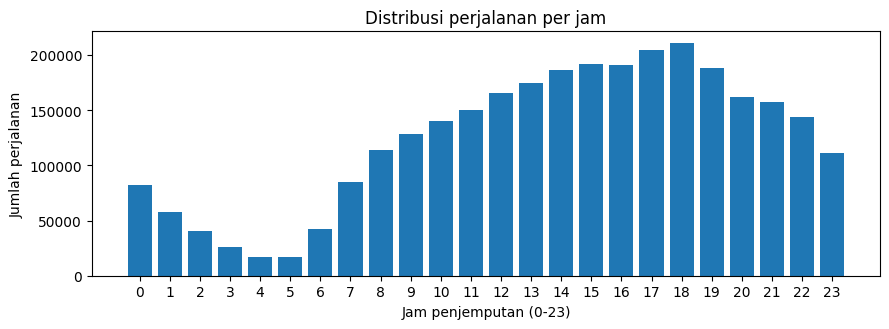

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

Latihan 1
Menentukan trip_distance terbesar

In [23]:
print(df["trip_distance"].sort_values(ascending=False).head(5))


3046991    258928.15
3009826    225987.37
3027106    187872.33
3021750    116439.71
3064729     85543.66
Name: trip_distance, dtype: float64


In [24]:
print(df["trip_distance"])

0          0.97
1          1.10
2          2.51
3          1.90
4          1.43
           ... 
3066761    3.05
3066762    5.80
3066763    4.67
3066764    3.15
3066765    2.85
Name: trip_distance, Length: 3066766, dtype: float64


Latihan 4


In [25]:
import os

path_snappy = os.path.join(DIR_Kerja, "trips_snappy.parquet")
path_gzip = os.path.join(DIR_Kerja, "trips_gzip.parquet")

print("--- Proses Penyimpanan Parquet ---")
ukur("Tulis Parquet (Snappy)", lambda: bersih.to_parquet(path_snappy, compression="snappy", index=False))


ukur("Tulis Parquet (GZIP)", lambda: bersih.to_parquet(path_gzip, compression="gzip", index=False))


ukuran_snappy = os.path.getsize(path_snappy) / 1024**2
ukuran_gzip = os.path.getsize(path_gzip) / 1024**2

print("\n--- Perbandingan Ukuran File ---")
print(f"Ukuran Snappy : {ukuran_snappy:.1f} MB")
print(f"Ukuran GZIP   : {ukuran_gzip:.1f} MB")

--- Proses Penyimpanan Parquet ---
[Tulis Parquet (Snappy)] 346.38 s | RSS +1.4 MB
[Tulis Parquet (GZIP)] 397.86 s | RSS -0.3 MB

--- Perbandingan Ukuran File ---
Ukuran Snappy : 58.5 MB
Ukuran GZIP   : 46.3 MB


Latihan 5

In [26]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()

# 1. TULIS ULANG AGREGASI DENGAN SPARK SQL
sdf_bersih.createOrReplaceTempView("trips_bersih")

# Jalankan query SQL
hasil_spark_sql = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah,
        ROUND(AVG(trip_distance), 2) AS rata_jarak,
        ROUND(AVG(total_amount), 2) AS rata_tarif
    FROM trips_bersih
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")

print("--- Hasil Agregasi Spark SQL (5 Baris Pertama) ---")
hasil_spark_sql.show(5)

# 2. PEMBUKTIAN KONSISTENSI SECARA TERPROGRAM

df_spark_pandas = hasil_spark_sql.toPandas()

selisih_maksimum = (agregasi["jumlah_perjalanan"] - df_spark_pandas["jumlah"]).abs().max()
print(f"Selisih maksimum pada kolom jumlah: {selisih_maksimum}")

if selisih_maksimum == 0:
    print("Kesimpulan: Hasil perhitungan KONSISTEN (tidak ada selisih sama sekali).")
else:
    print("Kesimpulan: Terdapat selisih pada hasil perhitungan.")
spark.stop()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

--- Hasil Agregasi Spark SQL (5 Baris Pertama) ---
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+---+----

Studi Kasus


=== Tabel Ringkasan (12 Baris Pertama) ===


,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,False,0,35351,14.10,2.57
1,False,1,17516,13.04,2.66
2,False,2,9452,12.23,2.63
3,False,3,6238,12.87,2.72
4,False,4,6192,14.79,2.81
5,False,5,12462,14.63,2.82
6,False,6,35728,14.57,2.33
7,False,7,74157,14.66,2.07
8,False,8,98431,14.82,1.90
9,False,9,103263,15.03,1.90


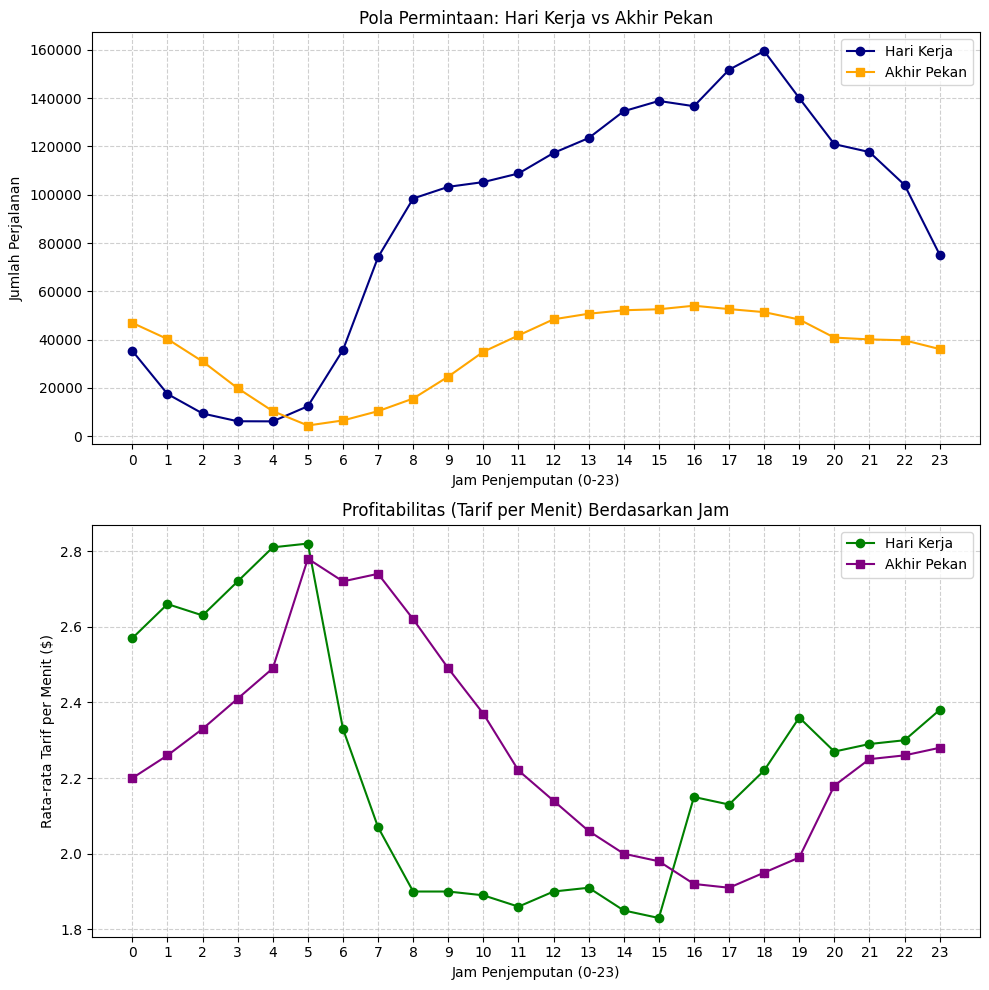

In [27]:
import matplotlib.pyplot as plt

# 1. Menyiapkan Dimensi Hari dan Profitabilitas
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

if "jam" not in bersih.columns:
    bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

# 2. Tabel Ringkasan
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

print("=== Tabel Ringkasan (12 Baris Pertama) ===")
display(ringkas.head(12))

# 3. Membuat Dua Grafik
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Pisahkan data untuk plotting
hari_kerja = ringkas[ringkas["akhir_pekan"] == False]
akhir_pekan = ringkas[ringkas["akhir_pekan"] == True]

# Grafik 1: Pola Jam Tertinggi/Terendah & Hari Kerja vs Akhir Pekan (Pertanyaan 1 & 2)
ax1.plot(hari_kerja["jam"], hari_kerja["jumlah"], label="Hari Kerja", marker="o", color="navy")
ax1.plot(akhir_pekan["jam"], akhir_pekan["jumlah"], label="Akhir Pekan", marker="s", color="orange")
ax1.set_title("Pola Permintaan: Hari Kerja vs Akhir Pekan")
ax1.set_xlabel("Jam Penjemputan (0-23)")
ax1.set_ylabel("Jumlah Perjalanan")
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Grafik 2: Profitabilitas (Tarif/Menit) di Jam Sibuk (Pertanyaan 3)
ax2.plot(hari_kerja["jam"], hari_kerja["rata_tarif_per_menit"], label="Hari Kerja", marker="o", color="green")
ax2.plot(akhir_pekan["jam"], akhir_pekan["rata_tarif_per_menit"], label="Akhir Pekan", marker="s", color="purple")
ax2.set_title("Profitabilitas (Tarif per Menit) Berdasarkan Jam")
ax2.set_xlabel("Jam Penjemputan (0-23)")
ax2.set_ylabel("Rata-rata Tarif per Menit ($)")
ax2.set_xticks(range(0, 24))
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

fig.tight_layout()
plt.show()

Rekomendasi 1 (Alokasi Armada): Maksimalkan pengerahan 1.200 armada pada jam puncak pukul 18:00 (mencapai [X] perjalanan) dan tarik armada untuk pemeliharaan saat titik terendah pukul 04:00, namun batasan analisis ini adalah data hanya mewakili satu bulan musim dingin sehingga pola saat musim liburan panas belum tentu sama.

Rekomendasi 2 (Penjadwalan Shift): Tunda jam mulai shift pengemudi di akhir pekan karena pola permintaan bergeser dan baru memuncak pada malam hari (akumulasi [X] perjalanan di atas pukul 19:00), dengan batasan bahwa data ini mungkin dipengaruhi anomali libur Tahun Baru yang tidak mencerminkan akhir pekan reguler.

Rekomendasi 3 (Strategi Keuntungan): Instruksikan pengemudi untuk tetap mengambil penumpang di area padat pada jam sibuk hari kerja karena profitabilitasnya mencapai titik tertinggi di angka $[X] per menit, dengan batasan bahwa perhitungan tarif ini belum dikurangi estimasi konsumsi bahan bakar tambahan akibat kemacetan.